In [ ]:
!pip install -U bitsandbytes transformers accelerate captum

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import sys

path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'qnli',
                'quantization': 'full',
                'training_mode': 'few shot 1 examples opposite',
                'model_id': 'meta-llama/Llama-3.2-3B-Instruct'}

# Create checkpoint
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /content/drive/MyDrive/eval_checkpoints/checkpoint_qnli_Llama_3.2_3B_Instruct_full_few_shot_1_examples_opposite.pt


In [ ]:
utils.hf_login("HF_TOKEN")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])
model = AutoModelForCausalLM.from_pretrained(
    global_params['model_id'],
    device_map="auto",
    attn_implementation="eager"
    )

# Add padding token to the tokenizer
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Change the model to evaluation mode
model.eval()

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((3072,), eps=1e-05)
    (

In [ ]:
# Upload qnli example indices
files.upload()

Saving qnli_few_shot_example_idx.npy to qnli_few_shot_example_idx.npy


{'qnli_few_shot_example_idx.npy': b"\x93NUMPY\x01\x00v\x00{'descr': '<i8', 'fortran_order': False, 'shape': (15,), }                                                           \n\xb3\x08\x00\x00\x00\x00\x00\x00 \x07\x00\x00\x00\x00\x00\x00\xc3\x14\x00\x00\x00\x00\x00\x00\xf8\x08\x00\x00\x00\x00\x00\x00\xff\x08\x00\x00\x00\x00\x00\x00\x89\x0f\x00\x00\x00\x00\x00\x00\x13\x05\x00\x00\x00\x00\x00\x00\xde\x03\x00\x00\x00\x00\x00\x00\xfc\x06\x00\x00\x00\x00\x00\x00l\x0b\x00\x00\x00\x00\x00\x00H\n\x00\x00\x00\x00\x00\x00w\x11\x00\x00\x00\x00\x00\x00\x07\x11\x00\x00\x00\x00\x00\x00\xe7\x0c\x00\x00\x00\x00\x00\x00\xe9\n\x00\x00\x00\x00\x00\x00"}

In [ ]:
# Lock 1 examples to be used for few shot
files.upload()
qnli_val = pd.read_csv('qnli_val.csv')
qnli_val["label"] = qnli_val["label"].map({0: "entailment", 1: "not entailment"})

demo_idxs = np.load('qnli_few_shot_example_idx.npy')

k = 1 # Examples to lock
demo_examples = qnli_val.iloc[demo_idxs[:k]]
qnli_val_few_shot = qnli_val.drop(qnli_val.index[demo_idxs])

# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nQuestion: {demo_examples.iloc[i]['question']}\nSentence: {demo_examples.iloc[i]['sentence']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Saving qnli_val.csv to qnli_val.csv


TypeError: string indices must be integers, not 'str'

In [ ]:
# Lock 1 examples to be used for few shot
# files.upload()
qnli_val = pd.read_csv('qnli_val.csv')
qnli_val["label"] = qnli_val["label"].map({0: "entailment", 1: "not entailment"})

demo_idxs = np.load('qnli_few_shot_example_idx.npy')

k = 1 # Examples to lock
demo_examples = qnli_val.iloc[demo_idxs[k]]
qnli_val_few_shot = qnli_val.drop(qnli_val.index[demo_idxs])

# Make examples for prompt
prompt_examples = ''
prompt_examples += f"Example 1\nQuestion: {demo_examples['question']}\nSentence: {demo_examples['sentence']}\nAnswer: {demo_examples['label']} \n\n"

print(prompt_examples)

Example 1
Question: Which well-known general abandoned Jamukha's coalition against Temüjin?
Sentence: Jamukha's assumption of this title was the final breach with Temüjin, and Jamukha formed a coalition of tribes to oppose him.
Answer: not entailment 




In [ ]:
demo_examples

,question,sentence,label,idx
2227,Which of his future general's fathers helped T...,The Tayichi'ud enslaved Temüjin (reportedly wi...,entailment,2227
1824,Which well-known general abandoned Jamukha's c...,Jamukha's assumption of this title was the fin...,not entailment,1824
5315,What local radio station is broadcast by the C...,The entrance to studio 5 at the City Road comp...,not entailment,5315
2296,When are subject committees established?,Subject Committees are established at the begi...,entailment,2296
2303,Who was the final Prime Minister of East Germany?,"Frederick William, Elector of Brandenburg, inv...",not entailment,2303
3977,What land was ceded to Spain?,France ceded its territory east of the Mississ...,not entailment,3977
1299,Is the output of a functional problem typicall...,Notable examples include the traveling salesma...,not entailment,1299
990,To what extent did Fermat confirm the validity...,Fermat also conjectured that all numbers of th...,entailment,990
1788,Where are some of the best medical facilities ...,"Today, Warsaw has some of the best medical fac...",entailment,1788
2924,What is it called when steam propels a turbo g...,It was found that steam turbines were not idea...,not entailment,2924


In [ ]:
qnli_val_few_shot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5448 entries, 0 to 5462
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  5448 non-null   object
 1   sentence  5448 non-null   object
 2   label     5448 non-null   object
 3   idx       5448 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 212.8+ KB


In [ ]:
qnli_val_few_shot.head()

,question,sentence,label,idx
0,What came into force after the new constitutio...,"As of that day, the new constitution heralding...",entailment,0
1,What is the first major city in the stream of ...,The most important tributaries in this area ar...,not entailment,1
2,What is the minimum required if you want to te...,In most provinces a second Bachelor's Degree s...,not entailment,2
3,How was Temüjin kept imprisoned by the Tayichi...,The Tayichi'ud enslaved Temüjin (reportedly wi...,entailment,3
4,"What did Herr Gott, dich loben wir become know...","He paraphrased the Te Deum as ""Herr Gott, dich...",not entailment,4


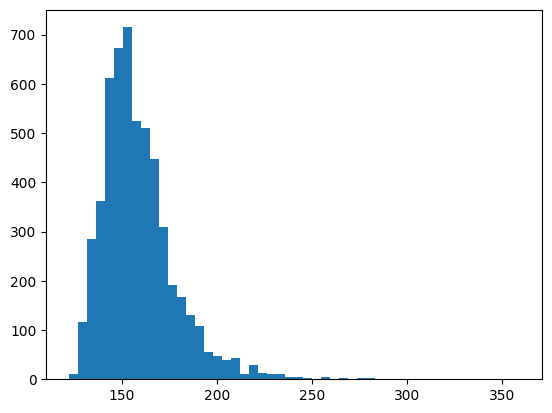

Max prompt length: 359
Max label length: 3


In [ ]:
# Find the max_length for tokenization to avoid wasting computing.
utils.find_max_length(qnli_val_few_shot, tokenizer=tokenizer, dataset_type=global_params['dataset_type'], examples=prompt_examples)

In [ ]:
prompt_lengths, _ = utils.get_lengths(qnli_val_few_shot, tokenizer, global_params['dataset_type'], examples=prompt_examples)
df = pd.DataFrame(prompt_lengths, columns=["length"])
tokens = 275 # Max length to check
n = (df["length"] > tokens).sum() # Number of prompts with # > tokens
percent = round(n/len(df)*100, 3)
print(f"Number of examples that have over {tokens} tokens and will be truncated: {n} out of {len(df)} examples or {percent}%")

Number of examples that have over 275 tokens and will be truncated: 6 out of 5448 examples or 0.11%


In [ ]:
# Define dataset and create a dataloader.
dataset_val = utils.MyDataset_few_shot(dataframe=qnli_val_few_shot,
                              examples=prompt_examples,
                               tokenizer=tokenizer,
                               dataset_type=global_params['dataset_type'],
                               prompt_max_length=275,
                               label_max_length=3)

batch_size = 80 # Change batch size according to GPU
dataloader = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

In [ ]:
# Test
predictions, gold_labels, batch_probs = utils.test_run(model=model,
                                          dataloader=dataloader,
                                          tokenizer=tokenizer,
                                          dataset_type=global_params['dataset_type'])

for i, pair in enumerate(zip(predictions, gold_labels)):
    print(pair, batch_probs[i])

('not entailment', 'entailment') tensor([0.0039, 0.9961])
('entailment', 'not entailment') tensor([0.9642, 0.0358])
('entailment', 'not entailment') tensor([0.8789, 0.1211])
('not entailment', 'entailment') tensor([0.0042, 0.9958])
('not entailment', 'not entailment') tensor([0.0122, 0.9878])
('not entailment', 'not entailment') tensor([0.1041, 0.8959])
('entailment', 'not entailment') tensor([0.8221, 0.1779])
('not entailment', 'not entailment') tensor([0.0965, 0.9035])
('entailment', 'not entailment') tensor([0.9169, 0.0831])
('not entailment', 'entailment') tensor([0.0475, 0.9525])
('entailment', 'not entailment') tensor([0.6065, 0.3935])
('not entailment', 'entailment') tensor([0.2801, 0.7199])
('not entailment', 'entailment') tensor([0.1952, 0.8048])
('not entailment', 'not entailment') tensor([0.2840, 0.7160])
('entailment', 'not entailment') tensor([0.5090, 0.4910])
('not entailment', 'entailment') tensor([0.0050, 0.9950])


In [ ]:
# Show an example prompt
print(dataset_val[0]['prompt'])

Examples:
Example 1
Question: Which well-known general abandoned Jamukha's coalition against Temüjin?
Sentence: Jamukha's assumption of this title was the final breach with Temüjin, and Jamukha formed a coalition of tribes to oppose him.
Answer: not entailment 

 
Given the above examples as reference does the sentence entail the question in the following case? Answer exactly one word in lowercase as in the examples: 'not entailment' or 'entailment'. 
sentence: As of that day, the new constitution heralding the Second Republic came into force. 
question: What came into force after the new constitution was herald? 
Answer:


In [ ]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        if torch.isnan(batch_probs).any():
            print("Warning: NaNs detected in batch_probs")

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

No checkpoint found.



Evaluating:   1%|▏         | 1/69 [00:06<07:53,  6.96s/batch]

Checkpoint saved: 1, /content/drive/MyDrive/eval_checkpoints/checkpoint_qnli_Llama_3.2_3B_Instruct_full_few_shot_1_examples_opposite.pt



Evaluating:  74%|███████▍  | 51/69 [04:58<01:45,  5.84s/batch]

Checkpoint saved: 51, /content/drive/MyDrive/eval_checkpoints/checkpoint_qnli_Llama_3.2_3B_Instruct_full_few_shot_1_examples_opposite.pt



Evaluating: 100%|██████████| 69/69 [06:38<00:00,  5.78s/batch]

Checkpoint saved: 69, /content/drive/MyDrive/eval_checkpoints/checkpoint_qnli_Llama_3.2_3B_Instruct_full_few_shot_1_examples_opposite.pt


Checkpoint found.
Accuracy: 0.5675.
 F1 Score: 0.5585.
 Matthew's Correlation Coefficient: 0.1372.
 Cohen's Kappa Score: 0.1323.


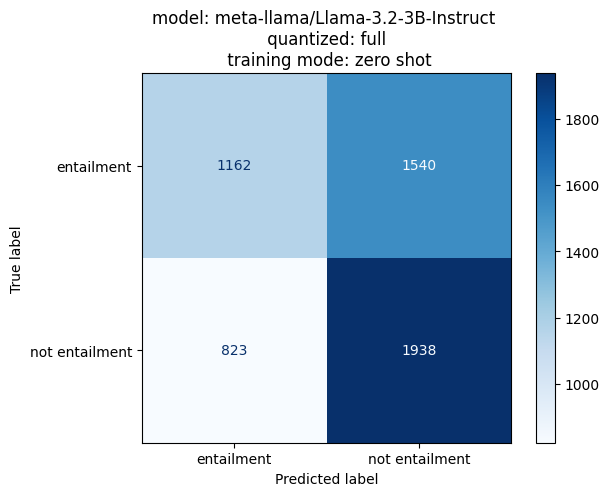

In [ ]:
# Calculate metrics with 0 examples
predicted_labels, gold_labels, batch = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.5521.
 Precision: 0.6745.
Recall: 0.5476.
F1 Score: 0.4495.
 Matthew's Correlation Coefficient: 0.1823.
 Cohen's Kappa Score: 0.0961.


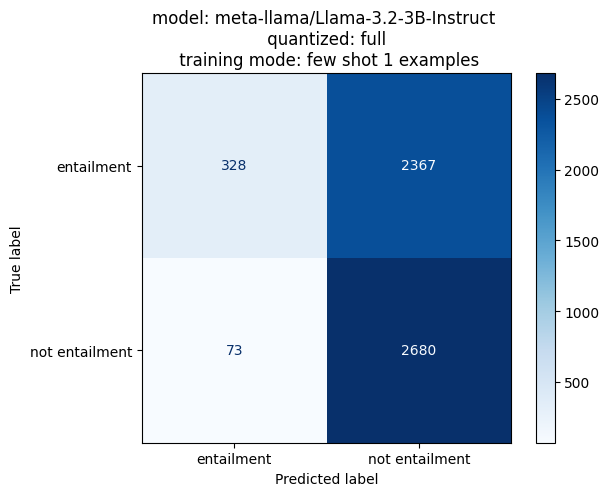

In [ ]:
# Calculate metrics with 1 examples
predicted_labels, gold_labels, batch = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.5828.
 Precision: 0.5859.
Recall: 0.5837.
F1 Score: 0.5803.
 Matthew's Correlation Coefficient: 0.1696.
 Cohen's Kappa Score: 0.1670.


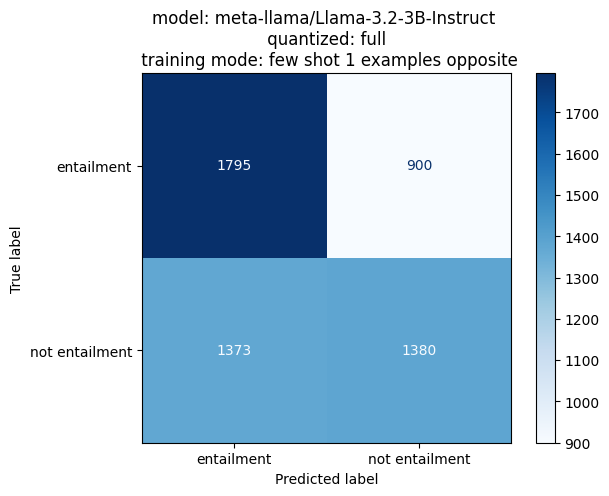

In [ ]:
# Calculate metrics with 1 opposite examples
predicted_labels, gold_labels, batch = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.5650.
 Precision: 0.5705.
Recall: 0.5663.
F1 Score: 0.5589.
 Matthew's Correlation Coefficient: 0.1368.
 Cohen's Kappa Score: 0.1322.


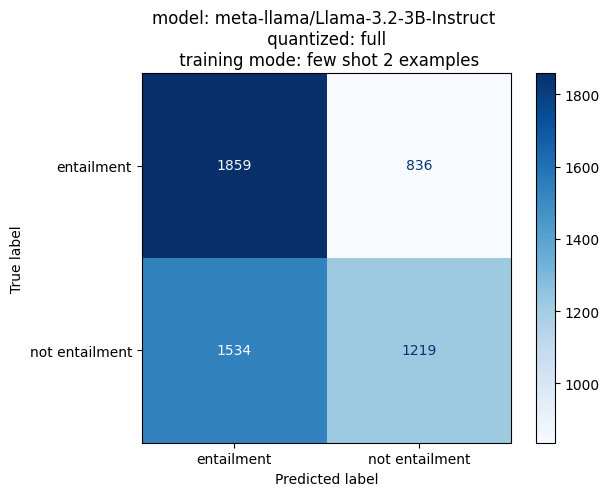

In [ ]:
# Calculate metrics with 2 examples
predicted_labels, gold_labels, batch = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.5767.
 Precision: 0.5863.
Recall: 0.5784.
F1 Score: 0.5674.
 Matthew's Correlation Coefficient: 0.1645.
 Cohen's Kappa Score: 0.1562.


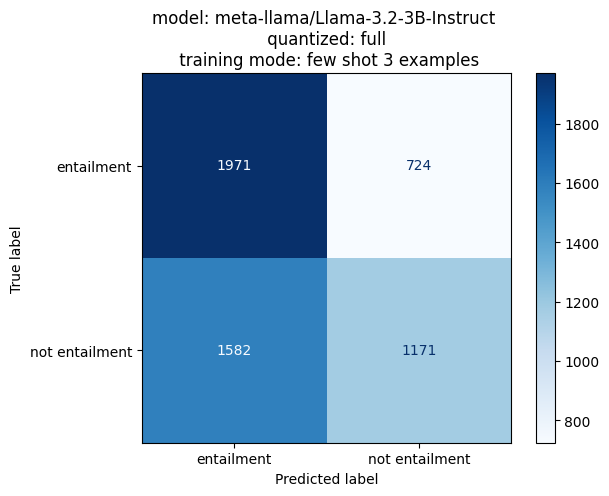

In [ ]:
# Calculate metrics with 3 examples
predicted_labels, gold_labels, batch = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.5720.
 Precision: 0.5757.
Recall: 0.5730.
F1 Score: 0.5685.
 Matthew's Correlation Coefficient: 0.1486.
 Cohen's Kappa Score: 0.1456.


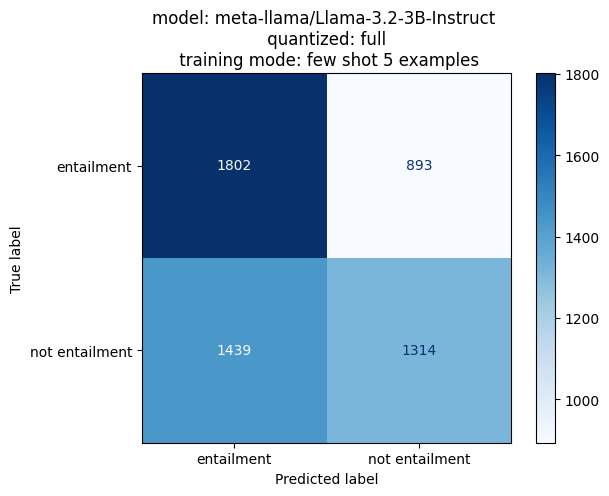

In [ ]:
# Calculate metrics with 5 examples
predicted_labels, gold_labels, batch = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.5598.
 Precision: 0.5611.
Recall: 0.5604.
F1 Score: 0.5588.
 Matthew's Correlation Coefficient: 0.1215.
 Cohen's Kappa Score: 0.1207.


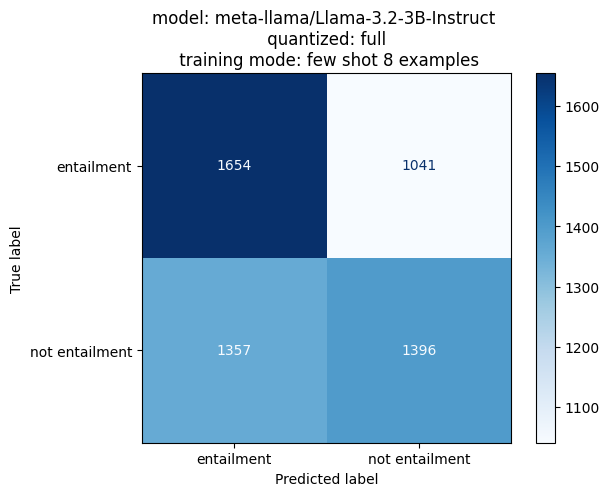

In [ ]:
# Calculate metrics with 8 examples
predicted_labels, gold_labels, batch = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.5787.
 Precision: 0.5833.
Recall: 0.5798.
F1 Score: 0.5748.
 Matthew's Correlation Coefficient: 0.1631.
 Cohen's Kappa Score: 0.1593.


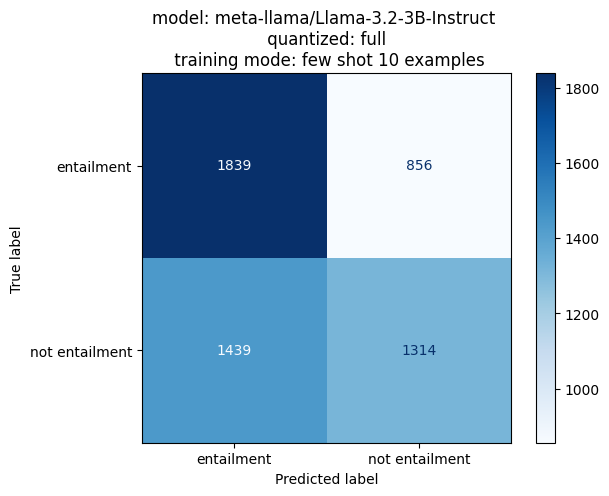

In [ ]:
# Calculate metrics with 10 examples
predicted_labels, gold_labels, batch = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.6158.
 Precision: 0.6201.
Recall: 0.6167.
F1 Score: 0.6134.
 Matthew's Correlation Coefficient: 0.2369.
 Cohen's Kappa Score: 0.2330.


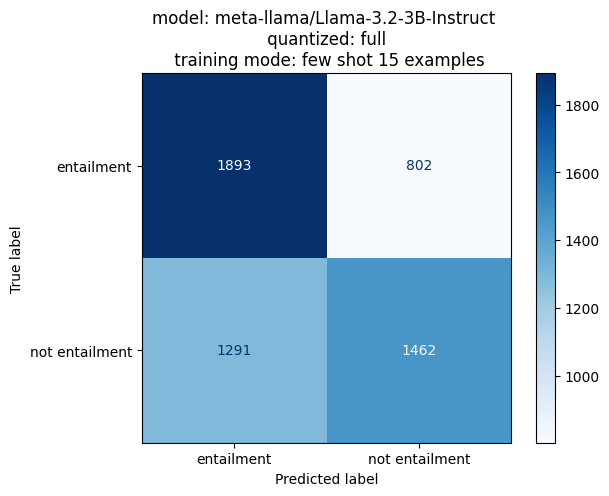

In [ ]:
# Calculate metrics with 15 examples
predicted_labels, gold_labels, batch = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.2_3B_Instruct/Few-Shot/checkpoint_qnli_Llama_3.2_3B_Instruct_full_few_shot_1_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.2_3B_Instruct/Few-Shot/checkpoint_qnli_Llama_3.2_3B_Instruct_full_few_shot_1_examples_opposite.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.2_3B_Instruct/Few-Shot/checkpoint_qnli_Llama_3.2_3B_Instruct_full_few_shot_2_examples.pt
Checkpoint found.
Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/QNLI_Notebooks/QNLI_Llama_3.2_3B_Instruct/Few-Shot/checkpoint_qnli_Llama_3.2_3B_Instruct_full_few_shot_3_examples.pt
Checkpoin

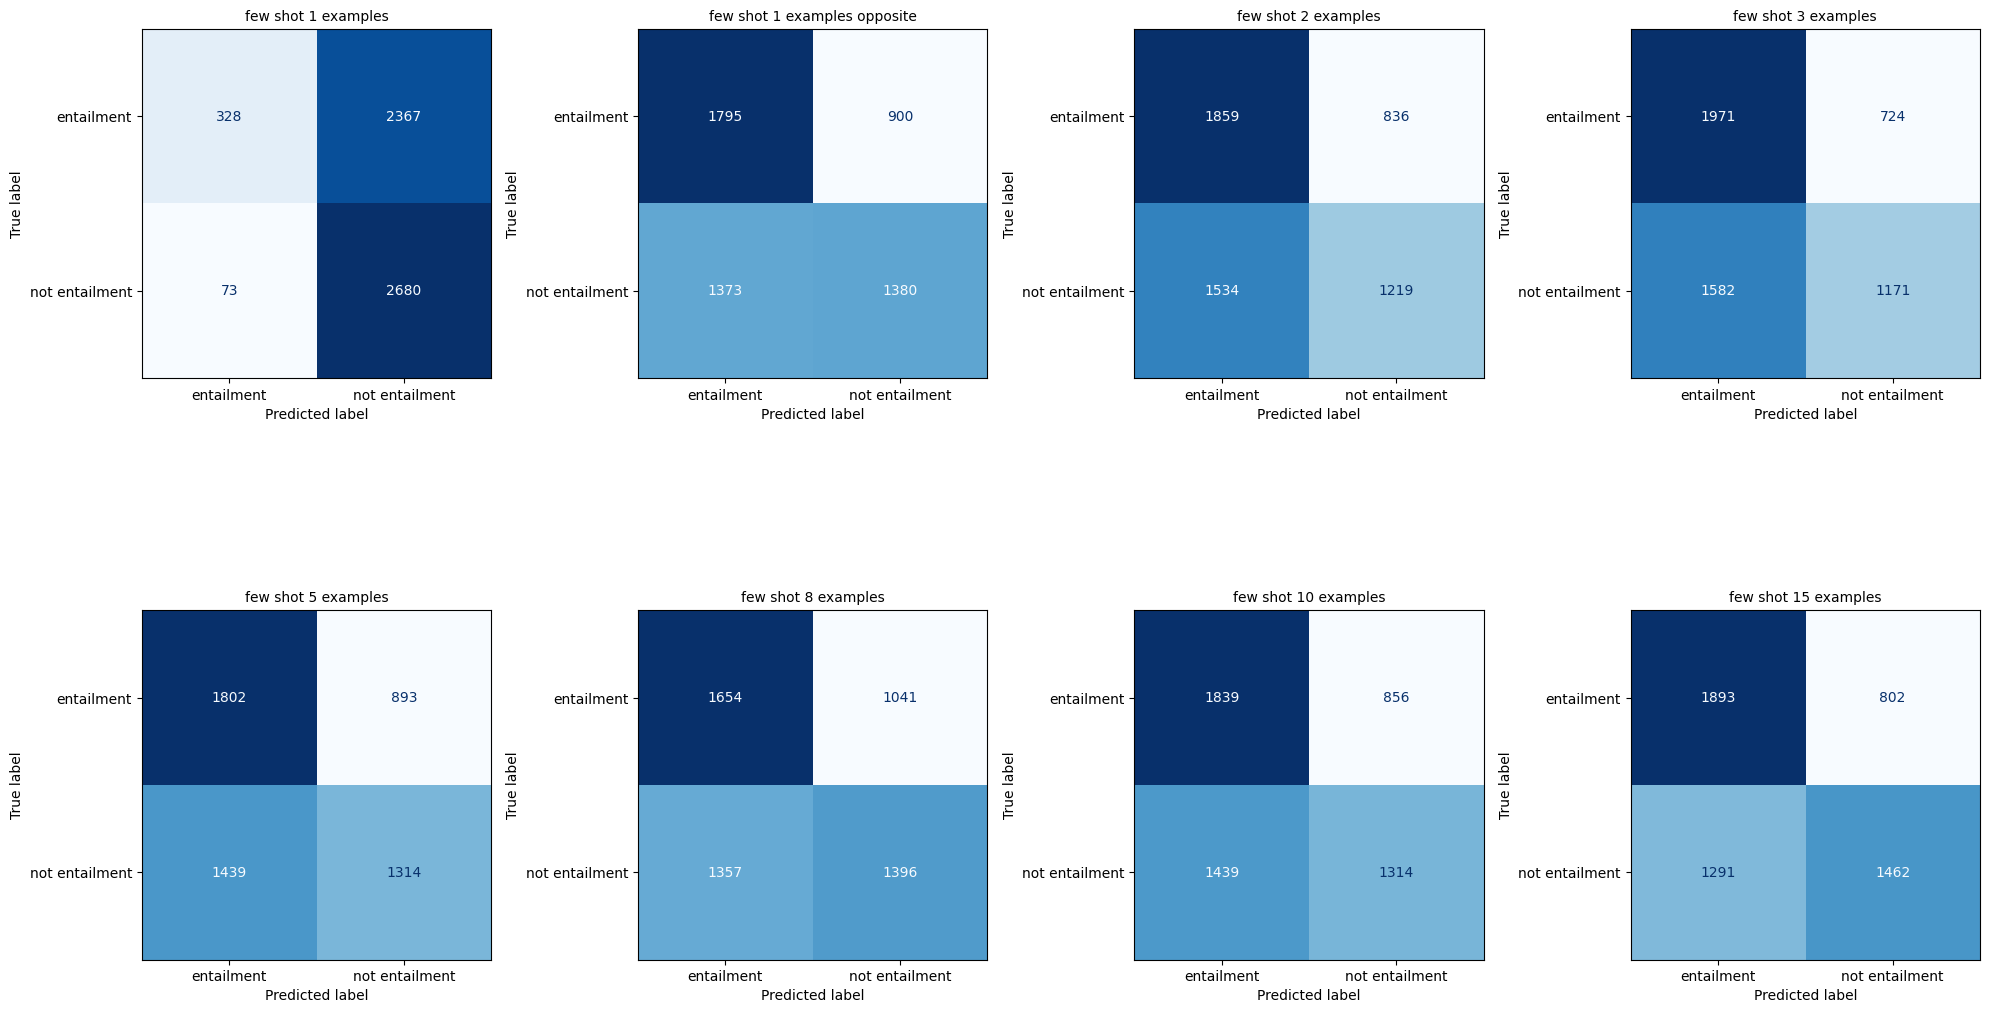

In [3]:
import matplotlib.pyplot as plt

examples_no = [1, 2, 3, 5, 8, 10, 15]
fig, axes = plt.subplots(2, 4, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

idx = 0
for k in examples_no:
    global_params = {
        'dataset_type': 'qnli',
        'quantization': 'full',
        'training_mode': f'few shot {k} examples',
        'model_id': 'meta-llama/Llama-3.2-3B-Instruct'
    }

    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

    idx += 1

    if k == 1:
        global_params = {
        'dataset_type': 'qnli',
        'quantization': 'full',
        'training_mode': f'few shot {k} examples opposite',
        'model_id': 'meta-llama/Llama-3.2-3B-Instruct'
    }

        checkpoint_path = utils.create_checkpoint_path(params=global_params)
        predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

        acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                                predicted_labels=predicted_labels,
                                                gold_labels=gold_labels,
                                                params=global_params,
                                                ax=axes[idx]
                                                )   
        accs.append(round(acc, 4))
        precisions.append(round(precision, 4))
        recalls.append(round(recall, 4))
        f1s.append(round(f1, 4))
        mccs.append(round(mcc, 4))
        kappas.append(round(kappa, 4))

        idx += 1


plt.tight_layout()
plt.show()

In [4]:
idx = [f"{k} examples" for k in examples_no]
idx.append("1 examples opposite")

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
    "F1": f1s,
    "MCC": mccs,
    "Kappa": kappas},
    index= idx
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
1 examples,0.5521,0.6745,0.5476,0.4495,0.1823,0.0961
2 examples,0.5828,0.5859,0.5837,0.5803,0.1696,0.1670
3 examples,0.5650,0.5705,0.5663,0.5589,0.1368,0.1322
5 examples,0.5767,0.5863,0.5784,0.5674,0.1645,0.1562
8 examples,0.5720,0.5757,0.5730,0.5685,0.1486,0.1456
10 examples,0.5598,0.5611,0.5604,0.5588,0.1215,0.1207
15 examples,0.5787,0.5833,0.5798,0.5748,0.1631,0.1593
1 examples opposite,0.6158,0.6201,0.6167,0.6134,0.2369,0.2330


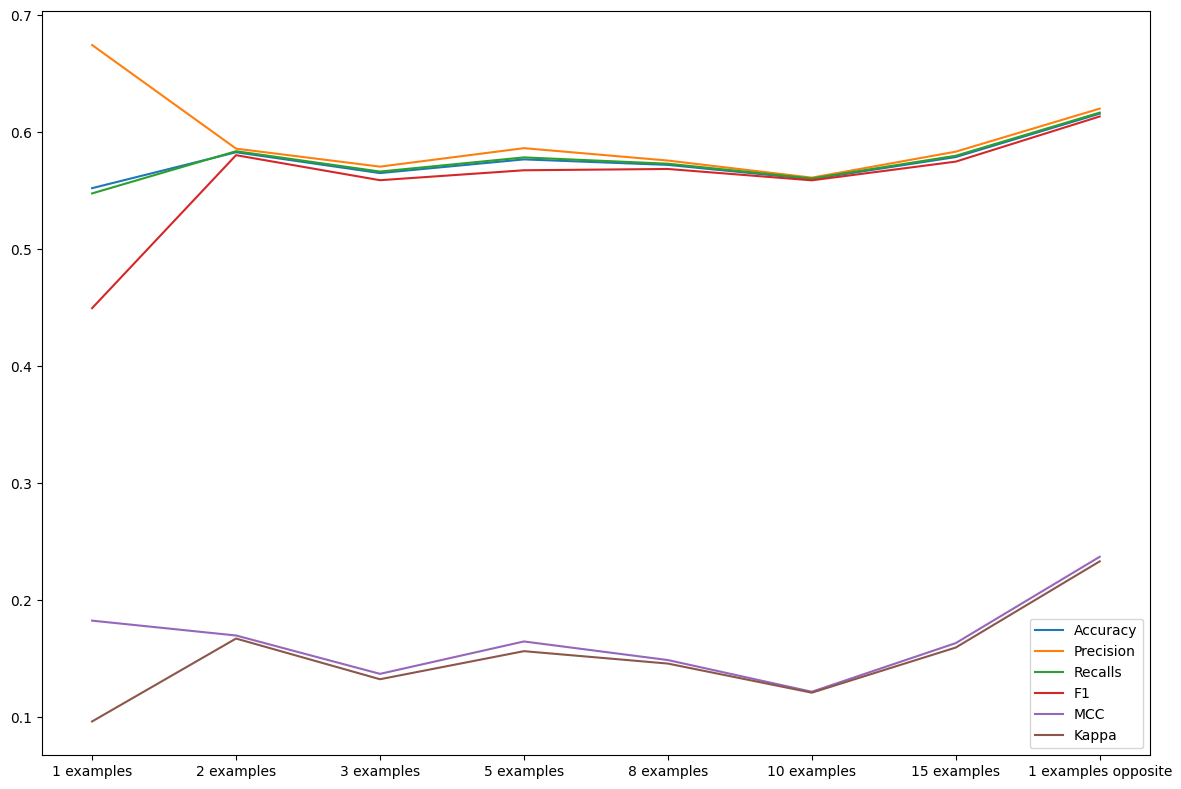

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
metrics_df.plot(kind='line', ax=ax)
plt.tight_layout()
plt.show()